#  Tech Assessment: Weather Trend Forecasting

Candidate: Sirpreet Kaur Dhillon <br>
Role: AI Engineer Intern - Technical Assessment<br>
Submission Date: March 4, 2026

## Objective
Analyze the "Global Weather Repository.csv" dataset to forecast future weather trends and showcase data science skills through both basic and advanced techniques.

## PM Accelerator Mission
"By making industry-leading tools and education available to individuals from all backgrounds, we level the playing field for future PM leaders. This is the PM Accelerator motto, as we grant aspiring and experienced PMs what they need most – Access. We introduce you to industry leaders, surround you with the right PM ecosystem, and discover the new world of AI product management skills."


### All Imports and Data injestion

Run the following command on your local computer to install all prerequisites 

pip install -r requirements.txt

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [10]:
# Set visualization style
sns.set_theme(style="whitegrid")

In [12]:
# Load Kaggle Dataset
df = pd.read_csv('GlobalWeatherRepository.csv')
df['last_updated'] = pd.to_datetime(df['last_updated'])
df = df.sort_values('last_updated').set_index('last_updated')

In [14]:
# Target: temperature_celsius (Global average daily)
target = df['temperature_celsius'].resample('D').mean().ffill()

In [15]:
# %% [2] Feature Engineering for ML Models
def create_features(series):
    df_feat = pd.DataFrame(series)
    df_feat['lag_1'] = series.shift(1)
    df_feat['lag_7'] = series.shift(7) # Weekly trend
    df_feat['rolling_mean_3'] = series.shift(1).rolling(window=3).mean()
    return df_feat.dropna()

In [16]:
data = create_features(target)
X = data.drop(columns=['temperature_celsius'])
y = data['temperature_celsius']

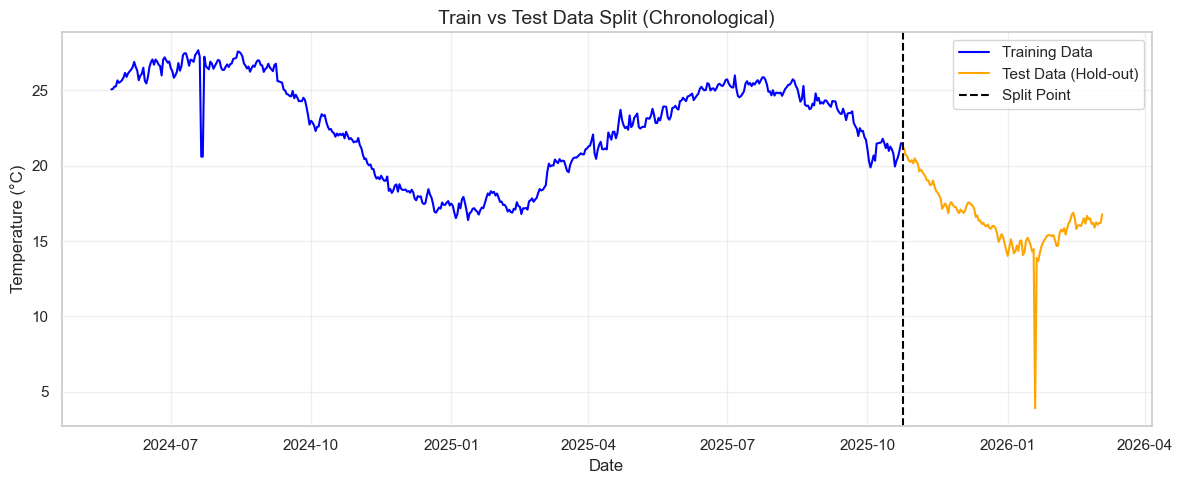

In [29]:
# 3. Visualizing the Split
plt.figure(figsize=(12, 5))

plt.plot(y_train.index, y_train, label='Training Data', color='blue')
plt.plot(y_test.index, y_test, label='Test Data (Hold-out)', color='orange')

plt.axvline(y_train.index.max(), color='black', linestyle='--', label='Split Point')

plt.title("Train vs Test Data Split (Chronological)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

** Removing outliers **

In [17]:
# Split data (80% Train, 20% Test)
split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [18]:
# %% [3] Building the Models
# Model 1: SARIMA (Statistical - captures seasonality)
sarima_model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,7)).fit(disp=False)
sarima_preds = sarima_model.predict(start=X_test.index[0], end=X_test.index[-1])

In [19]:
# Model 2: XGBoost (Tree Ensemble - captures non-linear jumps)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05).fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)



In [20]:
# Model 3: KNN (Instance-based - captures historical similarity)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn_model = KNeighborsRegressor(n_neighbors=5).fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)

In [21]:
# %% [4] The Ensemble (Simple Weighted Average)
# Weights can be adjusted based on individual model performance
ensemble_preds = (0.4 * sarima_preds) + (0.4 * xgb_preds) + (0.2 * knn_preds)

In [22]:
# %% [5] Comparison & Visualization
results = pd.DataFrame({
    'Actual': y_test,
    'SARIMA': sarima_preds,
    'XGBoost': xgb_preds,
    'KNN': knn_preds,
    'Ensemble': ensemble_preds
})

In [23]:
print("RMSE Scores:")
for col in ['SARIMA', 'XGBoost', 'KNN', 'Ensemble']:
    error = np.sqrt(mean_squared_error(y_test, results[col]))
    print(f"{col}: {error:.4f}")

RMSE Scores:
SARIMA: 4.3793
XGBoost: 1.7379
KNN: 1.7831
Ensemble: 2.7015


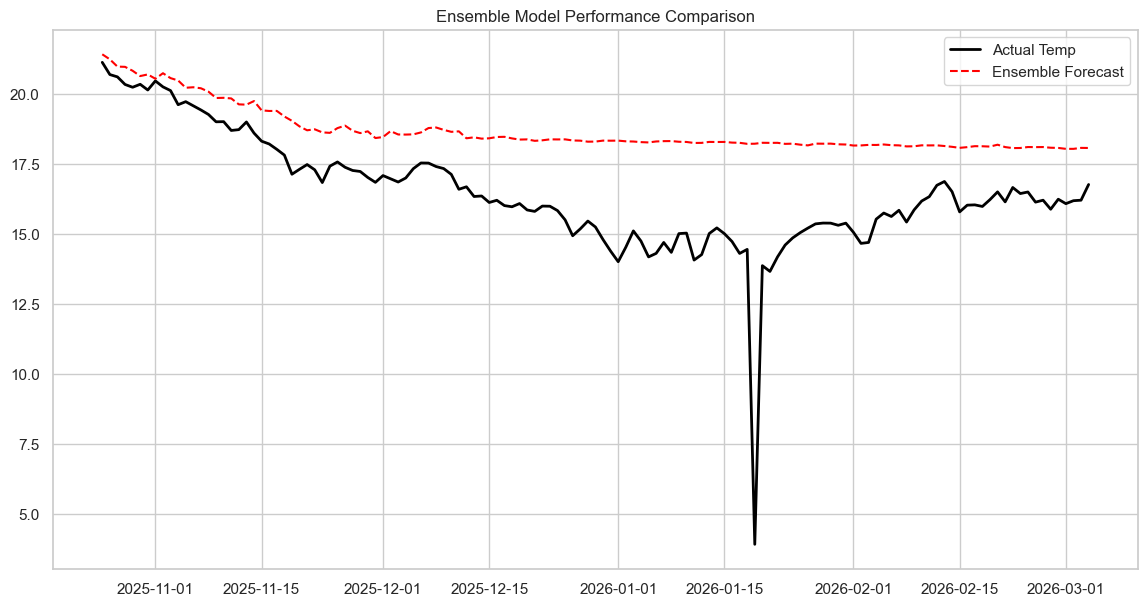

In [24]:
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Temp', color='black', lw=2)
plt.plot(y_test.index, ensemble_preds, label='Ensemble Forecast', linestyle='--', color='red')
plt.title("Ensemble Model Performance Comparison")
plt.legend()
plt.show()

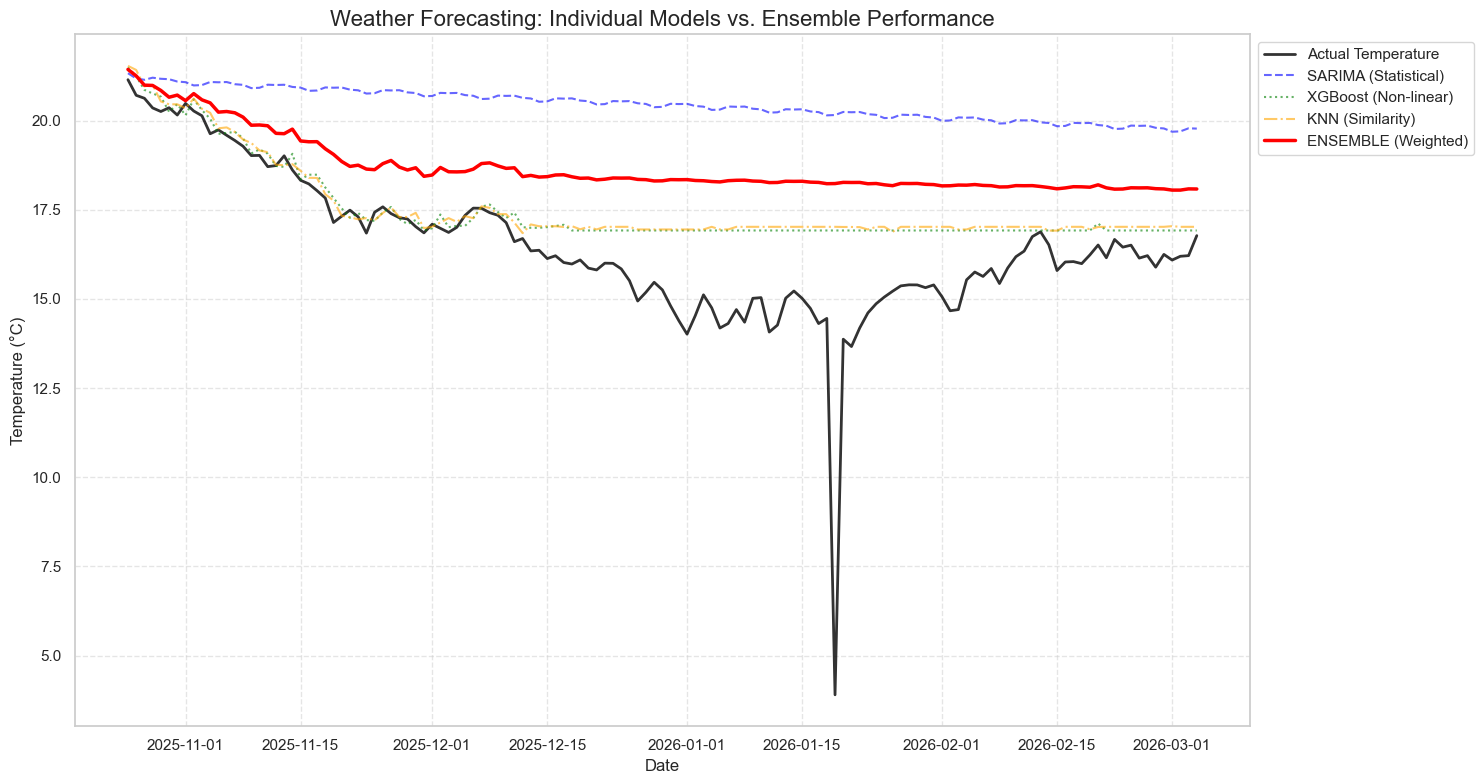

      Model      RMSE
1   XGBoost  1.737888
2       KNN  1.783100
3  Ensemble  2.701456
0    SARIMA  4.379266


In [25]:
# %% [1] Visualization: Models Comparison Plot
plt.figure(figsize=(15, 8))

# Plot Actual Data (The Ground Truth)
plt.plot(y_test.index, y_test, label='Actual Temperature', color='black', linewidth=2, alpha=0.8)

# Plot Individual Models (Use lighter colors and dashed/dotted lines for clarity)
plt.plot(y_test.index, sarima_preds, label='SARIMA (Statistical)', color='blue', linestyle='--', alpha=0.6)
plt.plot(y_test.index, xgb_preds, label='XGBoost (Non-linear)', color='green', linestyle=':', alpha=0.6)
plt.plot(y_test.index, knn_preds, label='KNN (Similarity)', color='orange', linestyle='-.', alpha=0.6)

# Plot the Ensemble (Bold color to make it stand out)
plt.plot(y_test.index, ensemble_preds, label='ENSEMBLE (Weighted)', color='red', linewidth=2.5)

# Aesthetics
plt.title("Weather Forecasting: Individual Models vs. Ensemble Performance", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Move legend outside to keep plot clean
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# %% [2] Error Analysis (Optional but recommended for the report)
error_df = pd.DataFrame({
    'Model': ['SARIMA', 'XGBoost', 'KNN', 'Ensemble'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, sarima_preds)),
        np.sqrt(mean_squared_error(y_test, xgb_preds)),
        np.sqrt(mean_squared_error(y_test, knn_preds)),
        np.sqrt(mean_squared_error(y_test, ensemble_preds))
    ]
})
print(error_df.sort_values(by='RMSE'))